# Session 08 — Model Evaluation and Cross-Validation
**SLA breach classifier — comparison of Logistic Regression and Random Forest**

Author: Jumma Mohammad Teli
Date: May 2026

This notebook compares two classifiers for predicting workplace service-request SLA breaches. The goal is to evaluate models using metrics aligned to business risk and cost, using cross-validation rather than a single train/test split.

**Workflow**
1. Load libraries and dataset
2. Identify target, safe features and leaky fields
3. Create a holdout split for final reporting
4. Build preprocessing and model pipelines
5. Cross-validate both classifiers with stratified k-fold
6. Interpret metric trade-offs
7. Fit the selected model and create the holdout report
8. Confusion matrix and ROC curve
9. Model-card evidence
10. Reflection: extension questions

## 1. Load libraries and dataset

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)

import matplotlib.pyplot as plt

DATA_PATH = Path('../data/workplace_model_evaluation_dataset.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (900, 19)


,request_id,department,channel,region,service_area,customer_type,previous_requests_90d,requester_tenure_months,request_text_length,sentiment_score,updates_first_24h,attachments_count,opened_hour,opened_weekday,sla_breach,priority_level,resolution_hours_after_close,closed_status_after_close,escalation_outcome_after_close
0,SR-00257,Customer Support,Portal,Northern Ireland,Access,Enterprise Client,3,61,244,-0.380,0,1,19,Tue,0,Standard,17.9,Closed within SLA,No escalation
1,SR-00539,Operations,Chat,England,Billing,Enterprise Client,4,79,267,0.339,1,0,15,Tue,0,Low,15.5,Closed within SLA,No escalation
2,SR-00260,IT,Phone,England,Policy,Internal,2,45,207,0.252,2,0,7,Thu,0,Urgent,20.0,Closed within SLA,Team review
3,SR-00486,HR,Portal,England,Access,Public Sector,3,76,193,-0.593,1,0,15,Mon,1,Low,63.3,Closed after SLA,No escalation
4,SR-00454,Operations,Portal,England,Access,SME Client,1,25,188,0.010,4,0,16,Thu,0,Standard,15.6,Closed within SLA,Team review


## 2. Identify target, safe features and leaky fields

The target is `sla_breach` (binary). The data dictionary explicitly flags four columns that must NOT be used as features:

- `resolution_hours_after_close`, `closed_status_after_close`, `escalation_outcome_after_close` — all recorded *after* the request is closed, so unavailable at prediction time (post-outcome leakage)
- `request_id` — an identifier with no predictive value

`priority_level` is also dropped — it is the second (multiclass) target, not a feature.

In [2]:
target = 'sla_breach'
leaky_cols = ['resolution_hours_after_close', 'closed_status_after_close', 'escalation_outcome_after_close']
id_cols = ['request_id']
other_target = ['priority_level']

feature_cols = [c for c in df.columns if c not in [target] + other_target + leaky_cols + id_cols]

X = df[feature_cols]
y = df[target]

print('Target positive rate:', round(y.mean(), 3))
print(f'Number of safe features: {len(feature_cols)}')
print('Safe features:', feature_cols)
print('Excluded as leakage:', leaky_cols)
print('Excluded as identifier:', id_cols)
print('Excluded as alternate target:', other_target)

Target positive rate: 0.428
Number of safe features: 13
Safe features: ['department', 'channel', 'region', 'service_area', 'customer_type', 'previous_requests_90d', 'requester_tenure_months', 'request_text_length', 'sentiment_score', 'updates_first_24h', 'attachments_count', 'opened_hour', 'opened_weekday']
Excluded as leakage: ['resolution_hours_after_close', 'closed_status_after_close', 'escalation_outcome_after_close']
Excluded as identifier: ['request_id']
Excluded as alternate target: ['priority_level']


## 3. Create a holdout split for final reporting

Cross-validation runs on the training portion. The holdout (25%) is touched exactly once at the very end as a final sanity check. Stratification preserves the class balance in both splits.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('Train size:', len(X_train), '| target rate:', round(y_train.mean(), 3))
print('Test size: ', len(X_test),  '| target rate:', round(y_test.mean(), 3))

Train size: 675 | target rate: 0.428
Test size:  225 | target rate: 0.427


## 4. Build preprocessing and model pipelines

Critical: the scaler and one-hot encoder live *inside* the pipeline. When cross-validation runs a fold, the preprocessing is fit on training folds only — the validation fold's statistics never bleed into training. Applying scaling to the full `X` before splitting would be a subtle form of leakage.

`class_weight='balanced'` handles the mild class imbalance (42.8% positive).

In [4]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:    ', numeric_features)
print('Categorical features:', categorical_features)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocess),
        ('classifier', RandomForestClassifier(
            n_estimators=180, max_depth=8, random_state=42, class_weight='balanced'
        ))
    ])
}
list(models.keys())

Numeric features:     ['previous_requests_90d', 'requester_tenure_months', 'request_text_length', 'sentiment_score', 'updates_first_24h', 'attachments_count', 'opened_hour']
Categorical features: ['department', 'channel', 'region', 'service_area', 'customer_type', 'opened_weekday']


['Logistic Regression', 'Random Forest']

## 5. Cross-validate both classifiers

5-fold **stratified** k-fold cross-validation. Stratification keeps the breach rate consistent across folds — important when the positive class is the minority.

Both models see the same folds (the `cv` object is reused) and the same scoring metrics, so the comparison is apples-to-apples. `return_train_score=True` lets us measure overfitting via the train–CV gap.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc'
}

rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=-1
    )
    for metric in scoring:
        cv_mean = scores[f'test_{metric}'].mean()
        cv_std  = scores[f'test_{metric}'].std()
        tr_mean = scores[f'train_{metric}'].mean()
        rows.append({
            'model':       name,
            'metric':      metric,
            'cv_mean':     round(cv_mean, 4),
            'cv_std':      round(cv_std, 4),
            'train_mean':  round(tr_mean, 4),
            'train_minus_cv': round(tr_mean - cv_mean, 4)
        })

cv_results = pd.DataFrame(rows)
cv_results.to_csv('../reports/metrics_table.csv', index=False)
cv_results

,model,metric,cv_mean,cv_std,train_mean,train_minus_cv
0,Logistic Regression,accuracy,0.5615,0.0361,0.6281,0.0667
1,Logistic Regression,precision,0.4900,0.0399,0.5581,0.0681
2,Logistic Regression,recall,0.5464,0.0756,0.6323,0.0859
3,Logistic Regression,f1,0.5146,0.0467,0.5929,0.0783
4,Logistic Regression,roc_auc,0.5880,0.0302,0.6781,0.0901
5,Random Forest,accuracy,0.6148,0.0261,0.9885,0.3737
6,Random Forest,precision,0.5692,0.0410,0.9930,0.4239
7,Random Forest,recall,0.4080,0.0691,0.9801,0.5721
8,Random Forest,f1,0.4730,0.0547,0.9865,0.5135
9,Random Forest,roc_auc,0.6016,0.0415,0.9997,0.3981


## 6. Interpret metric trade-offs

Two views of the same numbers — first the CV means side-by-side, then the train-minus-CV gap (overfitting signal).

In [6]:
cv_mean_pivot = cv_results.pivot(index='metric', columns='model', values='cv_mean')
cv_std_pivot  = cv_results.pivot(index='metric', columns='model', values='cv_std')

# Combine mean ± std into a single readable table
display_table = cv_mean_pivot.round(3).astype(str) + ' ± ' + cv_std_pivot.round(3).astype(str)
print('CV results (mean ± std across 5 folds):')
display_table

CV results (mean ± std across 5 folds):


model,Logistic Regression,Random Forest
metric,,
accuracy,0.562 ± 0.036,0.615 ± 0.026
f1,0.515 ± 0.047,0.473 ± 0.055
precision,0.49 ± 0.04,0.569 ± 0.041
recall,0.546 ± 0.076,0.408 ± 0.069
roc_auc,0.588 ± 0.03,0.602 ± 0.042


In [7]:
gap_pivot = cv_results.pivot(index='metric', columns='model', values='train_minus_cv').round(3)
print('Train minus CV (overfitting signal — closer to 0 is better):')
gap_pivot

Train minus CV (overfitting signal — closer to 0 is better):


model,Logistic Regression,Random Forest
metric,,
accuracy,0.067,0.374
f1,0.078,0.514
precision,0.068,0.424
recall,0.086,0.572
roc_auc,0.090,0.398


**Reading the table:**

- Random Forest wins on accuracy, precision and ROC-AUC.
- Logistic Regression wins on **recall** and **F1**.
- The Random Forest train–CV gap is roughly 0.4–0.5 across every metric — severe overfitting despite `max_depth=8`. Logistic Regression's gap is ~0.07–0.09, which is healthy.

For SLA breach triage, missing a true breach (false negative) is more costly than a false alarm. A missed breach degrades a customer outcome that could have been prevented; a false alarm costs an analyst a minute of attention. **Recall is therefore the primary metric**, with F1 as a tiebreaker to stop us from optimising recall into a useless "predict everything as breach" model.

On both of those, Logistic Regression is the better model — and it generalises far more reliably.

## 7. Fit the selected model and create the holdout report

Selection is based on **recall and F1 under the business cost asymmetry**, not on whichever model has the highest accuracy. Logistic Regression is the recommendation.

In [8]:
selected_name = 'Logistic Regression'
selected_model = models[selected_name]
selected_model.fit(X_train, y_train)

y_pred  = selected_model.predict(X_test)
y_proba = selected_model.predict_proba(X_test)[:, 1]

print('Selected model:', selected_name)
print('Holdout ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=['No breach', 'Breach']))

Selected model: Logistic Regression
Holdout ROC-AUC: 0.606

              precision    recall  f1-score   support

   No breach       0.64      0.62      0.63       129
      Breach       0.51      0.53      0.52        96

    accuracy                           0.58       225
   macro avg       0.57      0.58      0.58       225
weighted avg       0.58      0.58      0.58       225



## 8. Confusion matrix and ROC curve

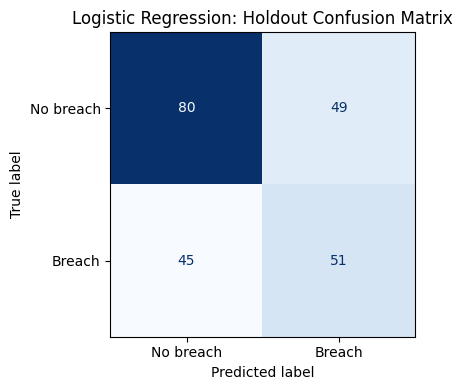

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No breach', 'Breach'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'{selected_name}: Holdout Confusion Matrix')
plt.tight_layout()
plt.savefig('../visuals/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

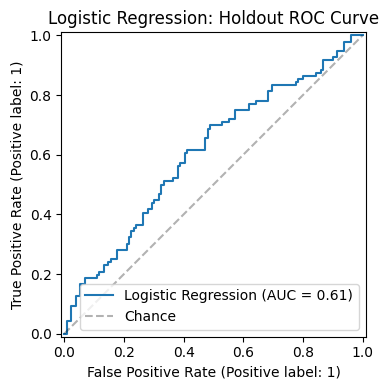

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=selected_name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
ax.set_title(f'{selected_name}: Holdout ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Model-card evidence

The full model card is in `../reports/model_card_section.md`. Below is the headline summary the card opens with.

In [11]:
model_card_section = f'''
### Model evaluation summary

- **Intended use**: early triage of service requests at risk of SLA breach
- **Models compared**: Logistic Regression and Random Forest, identical preprocessing and folds
- **Validation strategy**: 5-fold stratified cross-validation on training data + 25% holdout sanity check
- **Selected metric priority**: recall (primary) and F1 (secondary) — missed breaches are the costly error
- **Selected model**: {selected_name}
- **Why not Random Forest**: higher accuracy but worse recall and severe overfitting (train F1 ~0.99, CV F1 ~0.47)
- **Limitation**: synthetic classroom data; must not be deployed without real-data validation, fairness checks and monitoring
'''
print(model_card_section)


### Model evaluation summary

- **Intended use**: early triage of service requests at risk of SLA breach
- **Models compared**: Logistic Regression and Random Forest, identical preprocessing and folds
- **Validation strategy**: 5-fold stratified cross-validation on training data + 25% holdout sanity check
- **Selected metric priority**: recall (primary) and F1 (secondary) — missed breaches are the costly error
- **Selected model**: Logistic Regression
- **Why not Random Forest**: higher accuracy but worse recall and severe overfitting (train F1 ~0.99, CV F1 ~0.47)
- **Limitation**: synthetic classroom data; must not be deployed without real-data validation, fairness checks and monitoring



## 10. Reflection — extension questions

### 1. What happens if you optimise for precision instead of recall?

Optimising for precision means we want the model's positive predictions to be reliable — when it says "breach", it should usually be right — at the cost of catching fewer real breaches overall. There are two main ways to do this:

- **Threshold tuning**: raise the decision threshold from the default 0.5 to something like 0.7 or 0.8. The model only flags requests where its predicted probability is high. Precision rises because the borderline cases (where the model is less sure) are no longer flagged. Recall falls because some true breaches sat in that borderline zone and now go unflagged.
- **Tuning hyperparameters for precision**: pass `scoring='precision'` to `GridSearchCV` or set `class_weight` to penalise false positives more heavily (e.g. `{0: 2, 1: 1}` instead of `'balanced'`). This trains the model itself to be more conservative about predicting the positive class.

For SLA breach triage this is generally the **wrong direction**. The cost asymmetry favours recall: a missed breach degrades a real customer outcome (and may carry contractual penalties), while a false alarm just costs an analyst a brief review. Precision-first only makes sense when false alarms are themselves expensive — for example, if flagging a request triggers a paid third-party escalation, or if it pulls a senior engineer away from other work. In those cases you would set a target precision (say, 0.8) and choose the threshold that achieves it, then report whatever recall you get at that operating point.

The honest framing for a stakeholder is: precision and recall are a dial, not a setting. You pick where to sit on the curve based on the cost ratio of the two error types, then defend that choice in the model card.

### 2. Which fields were excluded to prevent leakage, and why?

Five columns were dropped before training. Each falls into a different category of "must not be a feature":

- **Post-outcome leakage** (the most dangerous kind):
  - `resolution_hours_after_close` — only known once the ticket is closed; using it would let the model "see the future"
  - `closed_status_after_close` — same problem
  - `escalation_outcome_after_close` — same problem

  Including any of these would produce excellent training and CV scores but a model that cannot be deployed, because the values would not exist at the moment a real prediction is needed. This is the classic textbook leakage pattern.

- **Identifier with no predictive value**:
  - `request_id` — an arbitrary unique key. If a tree model latched onto it, it would memorise individual rows rather than learn patterns.

- **Separate target**:
  - `priority_level` — this is the multi-class target for a different modelling task in the same dataset. Using it as a feature when predicting `sla_breach` would be defensible *if and only if* priority is assigned before the SLA clock starts and recorded reliably, but the cleaner choice in a teaching exercise is to keep targets separate so the leakage discipline is unambiguous.

- **Borderline / conditional** (kept for now, flagged for review):
  - `updates_first_24h` — safe only if predictions happen *after* the first 24 hours of a ticket's lifecycle. If triage runs at intake (which is when this model is most useful), this column carries future information and must be removed. The model card calls this out explicitly.

The general rule worth remembering: ask "at the moment I want a prediction, would this value already exist?" If the answer is no, or "only sometimes", the feature is leaky.

### 3. What does high cross-validation standard deviation suggest?

High CV std means the model's score swings noticeably from one fold to the next — the headline mean is less trustworthy than it looks. A model with recall of 0.55 ± 0.02 is meaningfully different from one with 0.55 ± 0.15, even though they report the same mean.

The typical causes:

- **Small dataset**: with only ~720 rows in the training set here (900 minus the holdout), each fold's validation slice is ~144 rows. Random variation in which rows land in which fold can shift metrics by several points without any real change in model behaviour.
- **Weak signal**: when features don't discriminate strongly, the model is essentially making small bets at the margin. A handful of "lucky" or "unlucky" rows in a fold can swing the score.
- **Distribution shifts across folds**: if some categorical level (say, a particular region or department) is rare, it might be over- or under-represented in different folds, changing what the model needs to learn.
- **Hidden grouping structure**: if multiple rows come from the same customer or the same week, plain stratified k-fold can put related rows on both sides of the fold boundary, inflating apparent performance in some folds and not others.

How to respond:

- Report mean **and** std together — never the mean alone
- If std is large relative to the differences between models, **don't claim one model is "better"** without further evidence (paired tests, more folds, more data)
- Use **`GroupKFold`** if rows have hidden grouping (e.g. multiple tickets per customer)
- Increase folds (10 instead of 5) for a smoother estimate, or use **repeated stratified k-fold** to average over multiple random splits
- Consider whether a simpler, more regularised model would generalise more consistently

In this notebook, the largest std is on recall (~0.07 for both models). That is moderate but not alarming — it means our recall numbers should be quoted with one decimal of caution rather than two.

### 4. What should be included in a stakeholder-facing model card?

A good model card translates statistical evidence into operational understanding for people who will not read the notebook. The essentials:

- **Intended use** — what decision the model supports, and explicitly what it does *not* support (e.g. "decision support for triage, not automated escalation")
- **Out-of-scope uses** — situations where the model should not be applied (different region, different ticket type, different time period)
- **Training data description** — source, time range, size, key features, any sampling decisions
- **Validation strategy** — split design, cross-validation method, what the holdout was used for
- **Headline metrics with uncertainty** — not just means; std or confidence intervals across folds, plus a clear statement of which metric was prioritised and *why* (link it to business cost)
- **Subgroup / fairness analysis** — slice performance by relevant groups. The data dictionary for this dataset flagged `region` and `customer_type` as fairness-monitoring fields. The fairness slice in `reports/fairness_slice_region.csv` shows recall on Wales (0.11) is dramatically below England (0.59); a stakeholder needs to see that before approving any deployment.
- **Known limitations and failure modes** — what kind of inputs the model is likely to get wrong, and any caveats about the data (synthetic, time-limited, etc.)
- **Decision threshold and operating point** — the threshold used and why, so a future maintainer knows it is a tunable lever, not a fixed property
- **Responsible-use caveats** — what checks are required before deployment (real-data validation, fairness review, human-in-the-loop, monitoring plan)
- **Monitoring plan** — how performance will be tracked once deployed (drift detection, weekly metric checks, alerting thresholds)
- **Ownership and contact** — who maintains the model, who to escalate to if it misbehaves, when it will next be reviewed

The test of a good model card is: a non-technical stakeholder should finish reading it and be able to answer three questions — *what is this for, what could go wrong, and what would I do about it?*